In [14]:
import osmnx as ox
import networkx as nx

In [7]:
CU = ox.geocode_to_gdf(['Champaign, Illinois, USA', 'Urbana, Illinois, USA'])

In [8]:
places = [
    "Champaign, Illinois, USA",
    "Urbana, Illinois, USA"
]
gdf = ox.geocode_to_gdf(places)

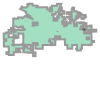

In [9]:
gdf.unary_union

In [10]:
G1 = ox.graph_from_polygon(gdf['geometry'][1], network_type="walk")
G0 = ox.graph_from_polygon(gdf['geometry'][0], network_type="walk")

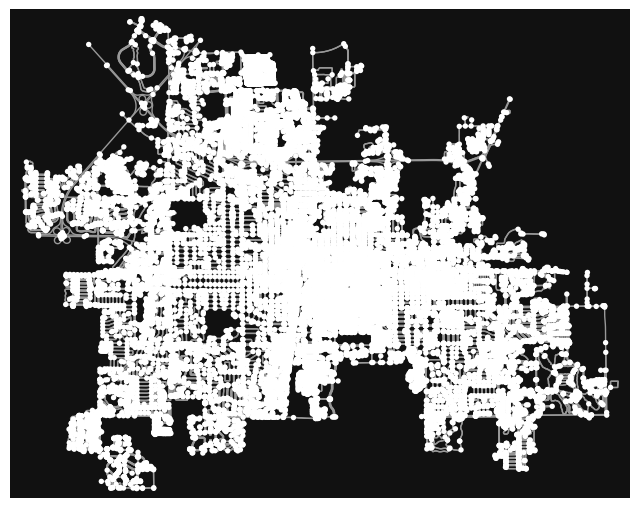

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
ox.plot_graph(ox.graph_from_polygon(gdf.unary_union))

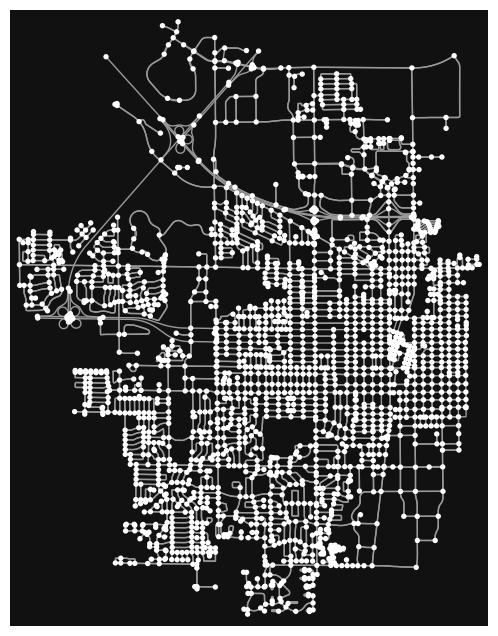

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [26]:
champaign = ox.graph_from_place('Champaign, IL, USA', network_type='drive')

ox.plot_graph(champaign)

In [49]:
nodes = champaign.nodes

for i,node in enumerate(nodes):
    if not i:
        print(node)
        print(champaign[node])

edges = champaign.edges

for i, edge in enumerate(edges):
    if not i:
        print(edge)
        print(champaign[edge[0]])
        print(champaign[edge[1]])

37945137
{38032634: {0: {'osmid': 237756215, 'oneway': True, 'name': 'West University Avenue', 'highway': 'primary', 'maxspeed': '30 mph', 'reversed': False, 'length': 141.592}}, 37945139: {0: {'osmid': 5324506, 'name': 'North Draper Avenue', 'highway': 'residential', 'maxspeed': '30 mph', 'oneway': False, 'reversed': False, 'length': 112.45400000000001, 'geometry': <LINESTRING (-88.27 40.116, -88.27 40.117, -88.27 40.117)>}}, 38033571: {0: {'osmid': 5333756, 'name': 'South Draper Avenue', 'highway': 'residential', 'maxspeed': '30 mph', 'oneway': False, 'reversed': False, 'length': 100.397, 'geometry': <LINESTRING (-88.27 40.116, -88.27 40.116, -88.27 40.116, -88.27 40.115)>}}}
(37945137, 38032634, 0)
{38032634: {0: {'osmid': 237756215, 'oneway': True, 'name': 'West University Avenue', 'highway': 'primary', 'maxspeed': '30 mph', 'reversed': False, 'length': 141.592}}, 37945139: {0: {'osmid': 5324506, 'name': 'North Draper Avenue', 'highway': 'residential', 'maxspeed': '30 mph', 'oneway

In [76]:
for node in nodes:
    info = champaign[node]
    s_4th = 0
    e_arm = 0
    for connecting_node in info:
        if not 'name' in champaign[node][connecting_node][0]:
            continue #== 'South Fourth Street':
        if champaign[node][connecting_node][0]['name'] == 'South Fourth Street' :
            s_4th = 1
        if champaign[node][connecting_node][0]['name'] == 'East Armory Avenue':
            e_arm = 1
        if s_4th + e_arm >= 2:
            print(champaign[node])
            #print(champaign[node], champaign[connecting_node])
        #print(1)

{37975592: {0: {'osmid': 5327716, 'oneway': False, 'lanes': '2', 'name': 'East Armory Avenue', 'highway': 'residential', 'reversed': True, 'length': 89.049, 'geometry': <LINESTRING (-88.233 40.105, -88.234 40.105, -88.234 40.105, -88.234 40.105,...>}}, 37975595: {0: {'osmid': 729125683, 'oneway': False, 'lanes': '2', 'name': 'East Armory Avenue', 'highway': 'unclassified', 'reversed': False, 'length': 127.323, 'geometry': <LINESTRING (-88.233 40.105, -88.233 40.105, -88.232 40.105)>}}, 38059714: {0: {'osmid': 729125684, 'name': 'South Fourth Street', 'highway': 'tertiary', 'maxspeed': '25 mph', 'oneway': False, 'reversed': False, 'length': 144.637, 'geometry': <LINESTRING (-88.233 40.105, -88.233 40.105, -88.233 40.105, -88.233 40.105,...>}}, 38089239: {0: {'osmid': 745436740, 'name': 'South Fourth Street', 'highway': 'tertiary', 'maxspeed': '25 mph', 'oneway': False, 'reversed': True, 'length': 129.005, 'geometry': <LINESTRING (-88.233 40.105, -88.233 40.106, -88.233 40.106, -88.233 4